In [149]:
import pandas as pd
import numpy as np
import re

In [150]:
def load_text(filename, encoding="utf-8"):
    """Load text file. Returns file content as string."""
    with open(filename, "r", encoding=encoding) as file:
        return file.read()

In [151]:
text_utf_8 = load_text("Alice in Wonderland.txt",'utf-8')
lines = text_utf_8.splitlines()

for line in lines[:5]:
    print(line)

The Project Gutenberg eBook of Alice in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms


In [152]:
try :
    text_ascii = load_text("Alice in Wonderland.txt",'ascii')
    lines = text_ascii.splitlines()

    for line in lines[:5]:
        print(line)

except UnicodeDecodeError:
    print(f"Could not read Alice in Wonderland.txt using ASCII encoding.")

Could not read Alice in Wonderland.txt using ASCII encoding.


In [153]:
text = load_text("Alice in Wonderland.txt",'utf-8')

In [154]:
total_char = len(text)
print(f"Total characters : {total_char}")

Total characters : 104111


In [155]:
words = re.findall(r"\b[\w'-]+\b", text)
total_words = len(words)
print(f"Total words :{total_words}")

Total words :18215


In [156]:
sentences = [s.strip() for s in re.split(r"[.!?]+", text) if s.strip()]
total_sentences = len(sentences)
print(f"Total sentences: {total_sentences}")

Total sentences: 1776


In [157]:
average_word_length = sum(len(word) for word in words) / total_words
print(f"Average word length: {average_word_length:.2f}")

Average word length: 4.32


In [158]:
average_sentence_length = total_words / total_sentences
print(f"Average sentence length: {average_sentence_length:.2f} words")

Average sentence length: 10.26 words


In [159]:
def make_df(total_words, text):
    """Create DataFrame with document metadata."""
    return pd.DataFrame({
        "Document_Id": [1],
        "Filename": ["Alice in Wonderland.txt"],
        "Word_count": [total_words],
        "Character_Count": [len(text)]
    })

df = make_df(total_words, text)
df.head()

,Document_Id,Filename,Word_count,Character_Count
0,1,Alice in Wonderland.txt,18215,104111


In [160]:
def save_csv(df, name="book.csv"):
    """Export DataFrame to CSV file."""
    df.to_csv(name, sep=",", index=False)

save_csv(df)

In [161]:
pattern = r'[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}'
#            username       @ domain      . extension
emails = re.findall(pattern, text)

In [162]:
print("Email addresses found:", emails)

Email addresses found: []


In [163]:
print(len(emails))

0


In [164]:
pattern = r'(?:\(\d{3}\)\s\d{3}-\d{4}|\d{3}-\d{3}-\d{4}|\+1-\d{3}-\d{3}-\d{4})'
phone_numbers = re.findall(pattern, text)

In [165]:
print(phone_numbers)

['(862) 621-9288']


In [166]:
for phone in phone_numbers:
    digits = re.sub(r'\D', '', phone)

    # Remove country code 1 if present
    if len(digits) == 11 and digits.startswith('1'):
        digits = digits[1:]

    normalized = digits[:3] + '-' + digits[3:6] + '-' + digits[6:]
    print(normalized)

862-621-9288


In [167]:
hashtags = re.findall(r'#\w+', text) # extract hastags
mentions = re.findall(r'@\w+', text) # extract mentions

In [168]:
print("Hashtags:", hashtags)
print("Username:", mentions)

Hashtags: ['#35688', '#516']
Username: []


In [169]:
from collections import Counter


pattern = r'https?://[^\s]+'
urls = re.findall(pattern, text)

In [170]:
print("URLs:")
for url in urls:
    print(url)

URLs:
https://www.pgdp.net
https://www.pgdp.net


In [171]:
domains = []

for url in urls:
    domain = re.search(r'https?://([^/]+)', url)
    if domain:
        domains.append(domain.group(1))

In [172]:
domain_count = Counter(domains)

print("\nURLs by domain:")
for domain, count in domain_count.items():
    print(domain, ":", count)


URLs by domain:
www.pgdp.net : 2


In [173]:
date_pattern = r'\b(?:\d{2}/\d{2}/\d{4}|\d{2}-\d{2}-\d{4}|(?:January|February|March|April|May|June|July|August|September|October|November|December) \d{2}, \d{4})\b'

dates = re.findall(date_pattern, text)

print("Dates:")
for date in dates:
    print(date)

Dates:
March 26, 2011
March 23, 1915


In [174]:
currency_pattern = r'[$£€]\d+(?:\.\d{2})?'

amounts = re.findall(currency_pattern, text)

print("\nCurrency amounts:")
for amount in amounts:
    print(amount)


Currency amounts:
$1
$5


In [175]:
pattern = r'\b[a-zA-Z]+\b'
words = re.findall(pattern, text.lower())

In [176]:
word_frequency = Counter(words)

print("Word frequency dictionary:")
print(dict(word_frequency))

Word frequency dictionary:
{'the': 863, 'project': 89, 'gutenberg': 99, 'ebook': 13, 'of': 388, 'alice': 389, 'in': 227, 'wonderland': 12, 'this': 75, 'is': 129, 'for': 90, 'use': 20, 'anyone': 7, 'anywhere': 3, 'united': 15, 'states': 19, 'and': 477, 'most': 10, 'other': 39, 'parts': 2, 'world': 8, 'at': 114, 'no': 65, 'cost': 3, 'with': 144, 'almost': 5, 'restrictions': 2, 'whatsoever': 2, 'you': 528, 'may': 31, 'copy': 12, 'it': 344, 'give': 15, 'away': 16, 'or': 101, 're': 42, 'under': 11, 'terms': 23, 'license': 18, 'included': 3, 'online': 6, 'www': 12, 'org': 10, 'if': 110, 'are': 72, 'not': 83, 'located': 7, 'will': 28, 'have': 78, 'to': 409, 'check': 5, 'laws': 10, 'country': 6, 'where': 31, 'before': 24, 'using': 6, 'title': 1, 'author': 2, 'gerstenberg': 6, 'lewis': 5, 'carroll': 19, 'release': 1, 'date': 3, 'march': 48, 'recently': 1, 'updated': 2, 'january': 1, 'language': 3, 'english': 4, 'information': 9, 'formats': 2, 'ebooks': 8, 'credits': 1, 'produced': 6, 'by': 61, 

In [177]:
count = list(word_frequency.values())
frequency_array = np.array(count)

In [178]:
print("\nFrequency array:")
print(frequency_array)


Frequency array:
[863  89  99 ...   1   1   1]


In [179]:
mean = np.mean(frequency_array)
print("Mean:", mean)


median = np.median(frequency_array)
print("Median:", median)


std = np.std(frequency_array)
print("Standard deviation:", std)

Mean: 7.456495346013759
Median: 2.0
Standard deviation: 33.34309020785787


In [180]:
p25 = np.percentile(frequency_array, 25)
print("\n25th percentile:", p25)


p50 = np.percentile(frequency_array, 50)
print("50th percentile:", p50)


p75 = np.percentile(frequency_array, 75)
print("75th percentile:", p75)


25th percentile: 1.0
50th percentile: 2.0
75th percentile: 4.0


In [181]:
char = re.findall(r'[a-zA-Z]', text.lower())

In [182]:
char_frequency = Counter(char)

print("Character frequency:")
print(dict(char_frequency))

Character frequency:
{'t': 7217, 'h': 4234, 'e': 9548, 'p': 1321, 'r': 4409, 'o': 6098, 'j': 197, 'c': 2308, 'g': 1747, 'u': 2825, 'n': 4964, 'b': 1141, 'k': 933, 'f': 1458, 'a': 5897, 'l': 3168, 'i': 5366, 'w': 1824, 'd': 2819, 's': 4578, 'y': 1944, 'm': 1712, 'v': 639, 'z': 51, 'q': 256, 'x': 87}


In [183]:
most_common = char_frequency.most_common(1)
print("\nMost common character:", most_common)


Most common character: [('e', 9548)]


In [184]:
least_common = min(char_frequency.items(), key=lambda x: x[1])
print("Least common character:", least_common)

Least common character: ('z', 51)


In [185]:
vowels = 'aeiou'

vowel_count = 0
consonant_count = 0

In [186]:
for c in char:
    if c in vowels:
        vowel_count += 1
    else:
        consonant_count += 1

ratio = vowel_count / consonant_count

In [187]:
print("Vowels:", vowel_count)
print("Consonants:", consonant_count)
print("Vowel to consonant ratio:", ratio)

Vowels: 29734
Consonants: 47007
Vowel to consonant ratio: 0.6325440891782075


In [188]:
sentences = re.split(r'(?<=[.!?])\s+', text.strip())

print("Total sentences:", len(sentences))

Total sentences: 1404


In [189]:
len_sentences = []

for sentence in sentences:
    words = re.findall(r'\b[a-zA-Z]+\b', sentence)
    len_sentences.append(len(words))

In [190]:
print("Sentence length distribution:")
print(len_sentences)

Sentence length distribution:
[37, 29, 27, 95, 4, 36, 6, 2, 1, 2, 19, 1, 42, 13, 13, 10, 12, 15, 2, 8, 1, 1, 34, 13, 3, 46, 13, 8, 6, 5, 8, 8, 6, 5, 26, 12, 6, 24, 5, 10, 28, 5, 3, 12, 11, 5, 13, 11, 6, 2, 5, 9, 7, 15, 6, 9, 5, 24, 10, 8, 1, 36, 7, 11, 21, 15, 14, 2, 2, 5, 7, 8, 19, 13, 7, 34, 9, 41, 13, 1, 36, 14, 1, 8, 12, 9, 28, 14, 12, 11, 16, 10, 21, 20, 3, 22, 6, 12, 12, 12, 25, 9, 34, 8, 7, 4, 3, 18, 7, 3, 39, 49, 3, 6, 10, 7, 44, 6, 5, 5, 10, 12, 6, 19, 8, 3, 19, 33, 3, 24, 48, 20, 16, 20, 10, 11, 9, 18, 24, 28, 11, 4, 25, 19, 6, 12, 15, 7, 6, 4, 4, 5, 4, 7, 1, 6, 11, 6, 12, 26, 7, 16, 17, 7, 13, 8, 11, 25, 28, 7, 6, 16, 9, 9, 23, 5, 13, 22, 1, 2, 1, 10, 2, 13, 32, 2, 1, 11, 13, 4, 7, 19, 11, 36, 27, 7, 10, 10, 22, 11, 11, 20, 12, 5, 17, 24, 9, 6, 14, 9, 11, 9, 19, 7, 11, 11, 12, 26, 10, 21, 7, 17, 8, 8, 13, 9, 10, 43, 7, 15, 20, 11, 4, 12, 17, 20, 19, 4, 3, 4, 5, 15, 8, 14, 2, 10, 6, 21, 8, 11, 11, 1, 14, 2, 3, 3, 4, 4, 7, 38, 7, 24, 12, 31, 2, 3, 4, 21, 9, 4, 1, 3, 6, 14, 3, 

In [191]:
len_array = np.array(len_sentences)


longest_index = np.argmax(len_array)
shortest_index = np.argmin(len_array)

In [192]:
print("Longest sentence:")
print(sentences[longest_index])
print("Length:", len_array[longest_index], "words")

Longest sentence:
INDEMNITY - You agree to indemnify and hold the Foundation, the
trademark owner, any agent or employee of the Foundation, anyone
providing copies of Project Gutenberg™ electronic works in
accordance with this agreement, and any volunteers associated with the
production, promotion and distribution of Project Gutenberg™
electronic works, harmless from all liability, costs and expenses,
including legal fees, that arise directly or indirectly from any of
the following which you do or cause to occur: (a) distribution of this
or any Project Gutenberg work, (b) alteration, modification, or
additions or deletions to any Project Gutenberg work, and (c) any
Defect you cause.
Length: 101 words


In [193]:
print("Shortest sentence:")
print(sentences[shortest_index])
print("Length:", len_array[shortest_index], "words")

Shortest sentence:
C.
Length: 1 words


In [194]:
import matplotlib.pyplot as plt

In [195]:
print(words)

['This', 'website', 'includes', 'information', 'about', 'Project', 'Gutenberg', 'including', 'how', 'to', 'make', 'donations', 'to', 'the', 'Project', 'Gutenberg', 'Literary', 'Archive', 'Foundation', 'how', 'to', 'help', 'produce', 'our', 'new', 'eBooks', 'and', 'how', 'to', 'subscribe', 'to', 'our', 'email', 'newsletter', 'to', 'hear', 'about', 'new', 'eBooks']


In [196]:
print(word_frequency)

Counter({'the': 863, 'you': 528, 'and': 477, 'i': 458, 'to': 409, 'a': 394, 'alice': 389, 'of': 388, 'it': 344, 's': 249, 'in': 227, 't': 225, 'queen': 175, 'that': 167, 'with': 144, 'is': 129, 'what': 126, 'at': 114, 'if': 110, 'all': 109, 'or': 101, 'do': 100, 'gutenberg': 99, 'on': 97, 'white': 95, 'be': 93, 'for': 90, 'project': 89, 'know': 86, 'her': 85, 'she': 84, 'not': 83, 'as': 83, 'they': 82, 'but': 80, 'have': 78, 'can': 78, 'this': 75, 'your': 74, 'king': 73, 'don': 73, 'are': 72, 'so': 72, 'out': 70, 'one': 66, 'no': 65, 'red': 63, 'oh': 62, 'by': 61, 'me': 59, 'there': 59, 'was': 58, 'we': 58, 'any': 57, 'he': 57, 'hatter': 56, 'his': 56, 'turtle': 55, 'like': 54, 'my': 52, 'duchess': 51, 'mock': 50, 'm': 50, 've': 50, 'would': 50, 'from': 49, 'march': 48, 'about': 48, 'rabbit': 47, 'off': 47, 'work': 47, 'hare': 44, 'when': 44, 're': 42, 'see': 41, 'course': 40, 'other': 39, 'why': 39, 'go': 39, 'only': 39, 'gryphon': 38, 'then': 38, 'them': 38, 'how': 37, 'just': 36, 'a

In [197]:
top_words = word_frequency.most_common(20)

words = [item[0] for item in top_words]
frequencies = [item[1] for item in top_words]

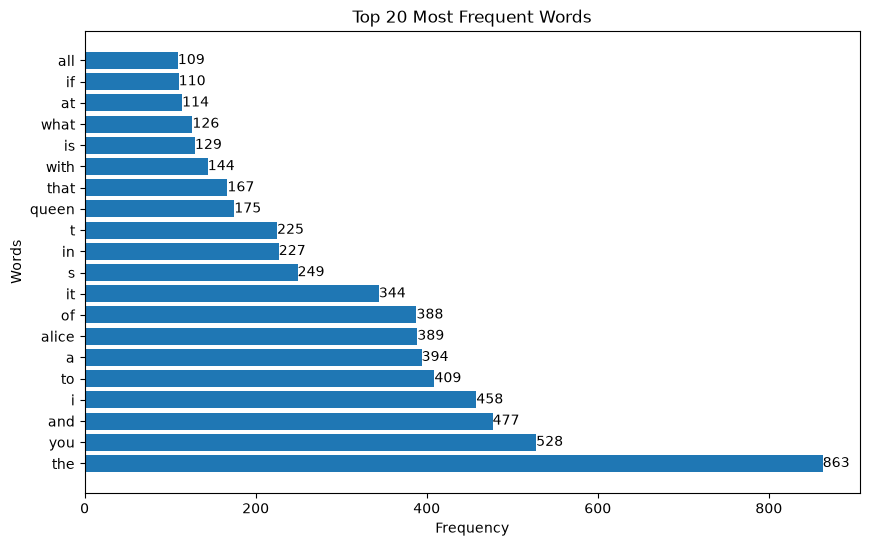

In [198]:
plt.figure(figsize=(10, 6))
bars = plt.barh(words, frequencies)
for bar in bars:
    value = bar.get_width()
    plt.text(value, bar.get_y() + bar.get_height()/2,
             str(value), va='center')

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words")

plt.show()

In [199]:
word_len = [len(word) for word in words]

mean = np.mean(word_len)
std = np.std(word_len)

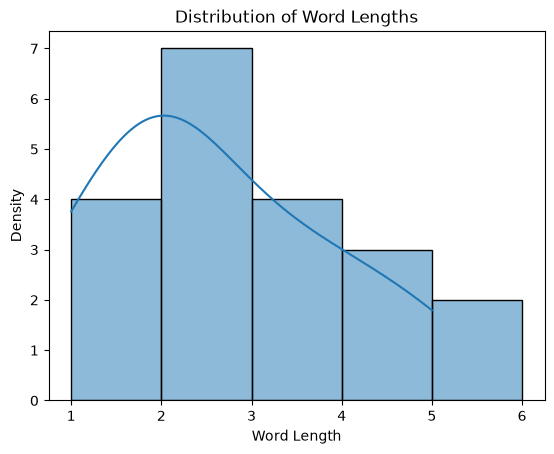

In [200]:
import seaborn as sns

sns.histplot(
    word_len,
    bins=range(1, max(word_len) + 2),
    kde=True
)

plt.xlabel("Word Length")
plt.ylabel("Density")
plt.title("Distribution of Word Lengths")

plt.show()

In [201]:
letters = re.findall(r'[a-zA-Z]', text.lower())
letter_frequency = Counter(letters)

top_letters = letter_frequency.most_common(15)

letters_list = [x[0] for x in top_letters]
letter_counts = [x[1] for x in top_letters]

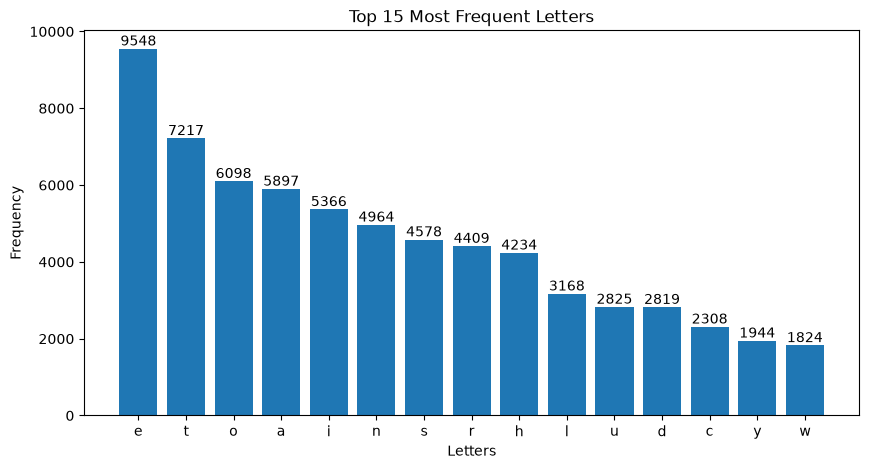

In [202]:
plt.figure(figsize=(10, 5))
bars = plt.bar(letters_list, letter_counts)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             str(int(bar.get_height())),
             ha='center', va='bottom')

plt.xlabel("Letters")
plt.ylabel("Frequency")
plt.title("Top 15 Most Frequent Letters")
plt.show()

In [203]:
punctuation = re.findall(r'[^\w\s]', text)
punctuation_frequency = Counter(punctuation)

top_punctuation = punctuation_frequency.most_common(15)

punct_list = [x[0] for x in top_punctuation]
punct_counts = [x[1] for x in top_punctuation]

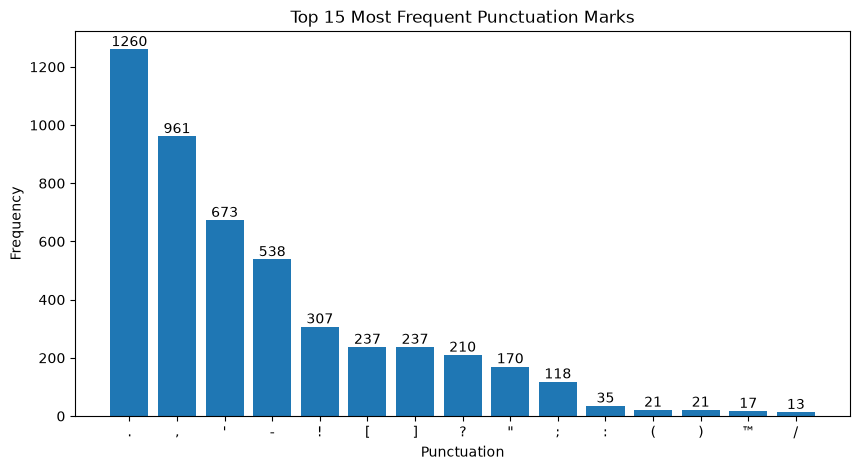

In [204]:
plt.figure(figsize=(10, 5))
bars = plt.bar(punct_list, punct_counts)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             str(int(bar.get_height())),
             ha='center', va='bottom')

plt.xlabel("Punctuation")
plt.ylabel("Frequency")
plt.title("Top 15 Most Frequent Punctuation Marks")
plt.show()

In [205]:
len_sentences = np.array(len_sentences)

Q1 = np.percentile(len_sentences, 25)
Q3 = np.percentile(len_sentences, 75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = len_sentences[
    (len_sentences < lower_limit) |
    (len_sentences > upper_limit)
]

print("Number of outliers:", len(outliers))
print("Outlier sentence lengths:", outliers)

Number of outliers: 110
Outlier sentence lengths: [ 37  95  36  42  34  46  36  34  41  36  34  39  49  44  33  48  32  36
  43  38  35  47  39  33  39  48  53  32  37  42  32  37  35  33  77  56
  33  52  33  51  32  33  46  45  33  37  64  63  60  55  40  34  39  49
  39  33  34  91  54  60  40  34  39  32  44  41  41  87  56  56  47  32
  38  35  36  76  35  32  54  33  53  43  33  41  83  37  56  37  33  43
  82  52  73  35  41  48  62  56  40  47  32  45  38 101  35  35  40  57
  39  39]


In [206]:
top_words = word_frequency.most_common(15)

word_names = [x[0] for x in top_words]
word_counts = [x[1] for x in top_words]

In [207]:
print("Word name:", word_names)
print("Word Count:", word_counts)

Word name: ['the', 'you', 'and', 'i', 'to', 'a', 'alice', 'of', 'it', 's', 'in', 't', 'queen', 'that', 'with']
Word Count: [863, 528, 477, 458, 409, 394, 389, 388, 344, 249, 227, 225, 175, 167, 144]


In [208]:
top_chars = char_frequency.most_common(15)

char_names = [x[0] for x in top_chars]
char_counts = [x[1] for x in top_chars]

In [209]:
print("Character name:", char_names)
print("Character count:", char_counts)

Character name: ['e', 't', 'o', 'a', 'i', 'n', 's', 'r', 'h', 'l', 'u', 'd', 'c', 'y', 'w']
Character count: [9548, 7217, 6098, 5897, 5366, 4964, 4578, 4409, 4234, 3168, 2825, 2819, 2308, 1944, 1824]


In [210]:
word_len

[3, 3, 3, 1, 2, 1, 5, 2, 2, 1, 2, 1, 5, 4, 4, 2, 4, 2, 2, 3]

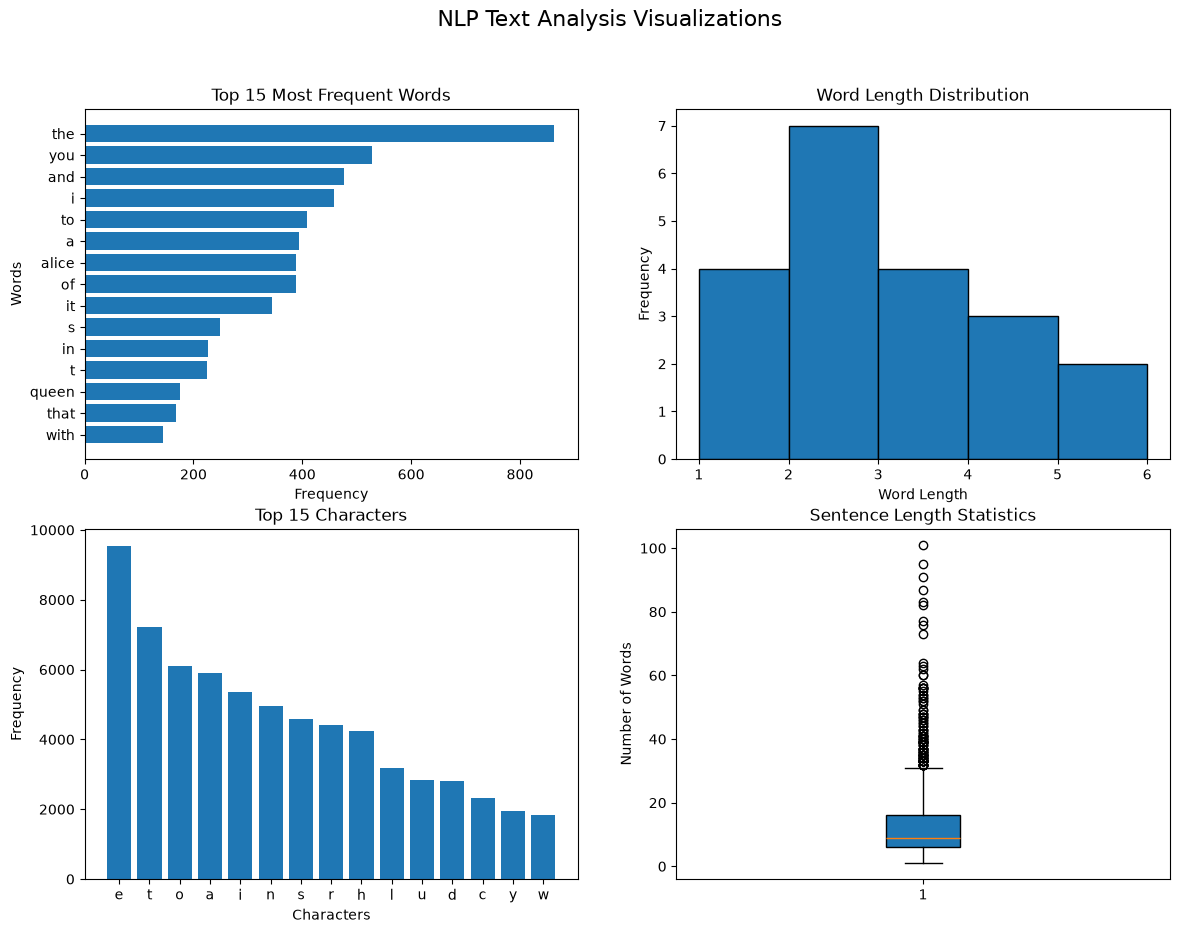

In [211]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].barh(word_names[::-1], word_counts[::-1])
axes[0, 0].set_title("Top 15 Most Frequent Words")
axes[0, 0].set_xlabel("Frequency")
axes[0, 0].set_ylabel("Words")

axes[0, 1].hist(word_len, bins=range(1, max(word_len) + 2),
                 edgecolor='black')
axes[0, 1].set_title("Word Length Distribution")
axes[0, 1].set_xlabel("Word Length")
axes[0, 1].set_ylabel("Frequency")

axes[1, 0].bar(char_names, char_counts)
axes[1, 0].set_title("Top 15 Characters")
axes[1, 0].set_xlabel("Characters")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].boxplot(len_sentences, patch_artist=True)
axes[1, 1].set_title("Sentence Length Statistics")
axes[1, 1].set_ylabel("Number of Words")

plt.suptitle("NLP Text Analysis Visualizations", fontsize=16)

plt.show()

In [212]:
data = []

In [213]:
for word, frequency in word_frequency.items():
    vowel_count = sum(1 for char in word if char in "aeiou")


    data.append([
        word,
        frequency,
        len(word),
        word[0],
        vowel_count
    ])

In [214]:
df = pd.DataFrame(
    data,
    columns=['word', 'frequency', 'length', 'first_char', 'vowel_count']
)

In [215]:
df.set_index('word', inplace=True)

In [216]:
df.head()

,frequency,length,first_char,vowel_count
word,,,,
the,863,3,t,1
project,89,7,p,2
gutenberg,99,9,g,3
ebook,13,5,e,3
of,388,2,o,1


In [217]:
length_group = df.groupby('length')['frequency'].agg(
    ['count', 'mean', 'median', 'sum']
)

print(length_group)

        count       mean  median   sum
length                                
1          15  98.200000    12.0  1473
2          45  66.288889    39.0  2983
3         160  25.912500     4.0  4146
4         397   8.556675     3.0  3397
5         437   5.720824     2.0  2500
6         414   3.429952     1.5  1420
7         356   2.929775     1.0  1043
8         255   1.992157     1.0   508
9         172   2.796512     1.0   481
10        119   2.378151     1.0   283
11         46   1.978261     1.0    91
12         32   2.218750     1.0    71
13         11   1.181818     1.0    13
14          8   1.375000     1.0    11
15          3   1.333333     1.0     4
16          1   1.000000     1.0     1


In [218]:
first_char_group = df.groupby('first_char')['frequency'].agg(
    ['count', 'mean', 'sum']
)

print(first_char_group)

            count       mean   sum
first_char                        
a             146  15.089041  2203
b             120   5.208333   625
c             204   3.651961   745
d             147   5.523810   812
e             104   3.009615   313
f             143   3.916084   560
g              80   5.687500   455
h              99   8.515152   843
i              73  20.082192  1466
j              18   4.500000    81
k              31   7.645161   237
l             103   4.495146   463
m             120   6.041667   725
n              48   7.479167   359
o              62  17.387097  1078
p             189   2.841270   537
q              13  16.769231   218
r             120   3.700000   444
s             284   4.672535  1327
t             158  17.101266  2702
u              42   4.214286   177
v              29   4.275862   124
w             124  10.217742  1267
y              14  47.428571   664


In [219]:
top_50 = df.sort_values(
    by='frequency',
    ascending=False
).head(50)

print(top_50)

           frequency  length first_char  vowel_count
word                                                
the              863       3          t            1
you              528       3          y            2
and              477       3          a            1
i                458       1          i            1
to               409       2          t            1
a                394       1          a            1
alice            389       5          a            3
of               388       2          o            1
it               344       2          i            1
s                249       1          s            0
in               227       2          i            1
t                225       1          t            0
queen            175       5          q            3
that             167       4          t            1
with             144       4          w            1
is               129       2          i            1
what             126       4          w       

In [220]:
long_words = df[df['length'] > 10]
print(long_words)

               frequency  length first_char  vowel_count
word                                                    
restrictions           2      12          r            4
gerstenberg            6      11          g            3
information            9      11          i            5
distributed            6      11          d            4
proofreading           2      12          p            5
...                  ...     ...        ...          ...
solicitation           1      12          s            6
prohibition            1      11          p            5
unsolicited            1      11          u            5
international          1      13          i            6
necessarily            1      11          n            4

[101 rows x 4 columns]


In [221]:
print("\nPivot table:")
print(pd.pivot_table(
    df,
    values='frequency',
    index='length',
    aggfunc=['mean', 'sum']
))



Pivot table:
             mean       sum
        frequency frequency
length                     
1       98.200000      1473
2       66.288889      2983
3       25.912500      4146
4        8.556675      3397
5        5.720824      2500
6        3.429952      1420
7        2.929775      1043
8        1.992157       508
9        2.796512       481
10       2.378151       283
11       1.978261        91
12       2.218750        71
13       1.181818        13
14       1.375000        11
15       1.333333         4
16       1.000000         1


In [222]:

print("\nCross-tabulation:")
print(pd.crosstab(df['first_char'], df['length']))


Cross-tabulation:
length      1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16
first_char                                                                
a            1   5  11  14  29  23  16  14  13  16   1   2   0   1   0   0
b            1   2  10  23  24  27  15  12   6   0   0   0   0   0   0   0
c            1   1   6  19  35  31  41  21  19  15   4   7   3   1   0   0
d            1   2   7  26  16  18  19  25   9  13   7   3   1   0   0   0
e            1   2   8  11  14  23  13  10   9   7   4   1   0   1   0   0
f            1   0  11  30  23  27  23  14   8   6   0   0   0   0   0   0
g            0   1   2  15  26  12   9   5   5   3   2   0   0   0   0   0
h            1   1  11  27  13  19  14   6   6   0   1   0   0   0   0   0
i            1   7   5   2   2   4   6  10  11  11   6   3   3   1   1   0
j            1   0   2   5   2   3   3   0   1   0   1   0   0   0   0   0
k            0   0   2   9   9   5   2   3   1   0   0   0   0   0   0   0
l     

In [223]:
import json

def extract_patterns(text):
    """Extract regex patterns and return dict."""
    patterns = {
        "emails": re.findall(r'[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}', text),
        "phone_numbers": re.findall(r'(?:\(\d{3}\)\s\d{3}-\d{4}|\d{3}-\d{3}-\d{4}|\+1-\d{3}-\d{3}-\d{4})', text),
        "urls": re.findall(r'https?://[^\s]+', text),
        "hashtags": re.findall(r'#\w+', text),
        "mentions": re.findall(r'@\w+', text),
        "dates": re.findall(r'\b(?:\d{2}/\d{2}/\d{4}|\d{2}-\d{2}-\d{4}|(?:January|February|March|April|May|June|July|August|September|October|November|December) \d{2}, \d{4})\b', text),
        "currency_amounts": re.findall(r'[$£€]\d+(?:\.\d{2})?', text)
    }
    return patterns

patterns_dict = extract_patterns(text)
with open("patterns.json", "w", encoding="utf-8") as f:
    json.dump(patterns_dict, f, indent=2)
print("patterns.json generated.")


patterns.json generated.


In [224]:
def clean_text(raw_text):
    """Strip Gutenberg header/footer and return cleaned text."""
    start = raw_text.find("*** START OF THE PROJECT GUTENBERG EBOOK ALICE IN WONDERLAND ***")
    end = raw_text.find("*** END OF THE PROJECT GUTENBERG EBOOK ALICE IN WONDERLAND ***")
    if start != -1:
        raw_text = raw_text[start + len("*** START OF THE PROJECT GUTENBERG EBOOK ALICE IN WONDERLAND ***"):] 
    if end != -1:
        raw_text = raw_text[:end]
    return raw_text.strip()

cleaned = clean_text(text)
with open("clean_text.txt", "w", encoding="utf-8") as f:
    f.write(cleaned)
print("clean_text.txt generated.")


clean_text.txt generated.
